# Pick My Movie

## Modèles sans interface

## Imports

In [1]:
!pip install customtkinter
!pip install gensim

In [2]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import gensim.downloader as api
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity


## Chargement des données

In [3]:
movies        = pd.read_csv("movies.csv")
ratings       = pd.read_csv("ratings.csv", nrows=200000)
genome_scores = pd.read_csv("genome-scores.csv")
genome_tags   = pd.read_csv("genome-tags.csv")

movies["year"]        = movies["title"].str.extract(r'\((\d{4})\)').astype(float)
movies["title_clean"] = (movies["title"].fillna("").astype(str)
                          .str.lower()
                          .str.replace(r"\(.*?\)", "", regex=True)
                          .str.strip())

ratings["rating"] = pd.to_numeric(ratings["rating"], errors="coerce")

df_merged   = pd.merge(ratings, movies, on="movieId")
movie_stats = df_merged.groupby("title_clean").agg(
    mean_rating=("rating", "mean"),
    num_ratings=("rating", "count"),
    year=("year", "first"),
    genres=("genres", "first")
)

movie_counts   = ratings["movieId"].value_counts()
popular_movies = movie_counts[movie_counts >= 50].index
ratings_small  = ratings[ratings["movieId"].isin(popular_movies)]

movie_vectors = genome_scores.pivot_table(
    index="movieId", columns="tagId", values="relevance"
).fillna(0)
movie_vectors = movie_vectors.loc[movie_vectors.index.intersection(ratings_small["movieId"])]

genome = genome_scores.merge(genome_tags, on="tagId").merge(movies[["movieId", "title"]], on="movieId")


## Modèle 1 mood

In [4]:
model = api.load("fasttext-wiki-news-subwords-300")

In [6]:
def get_vector(text, model):
    # sécurité
    if not isinstance(text, str):
        return np.zeros(model.vector_size)
    words = text.lower().split()
    vectors = []
    for word in words:
        if word in model:
            vectors.append(model[word])
    # si aucun mot connu
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

def find_similar_tags_v2(input_text, tags, tag_vectors, model, top_n=5):
    input_list = [w.strip().lower() for w in input_text.split(",")]
    results = []
    for word in input_list:
        if word == "":
            continue
        if word in tags:
            idx = tags.index(word)
            word_vec = tag_vectors[idx]
        else:
            word_vec = get_vector(word, model)
        similarities = cosine_similarity(
            word_vec.reshape(1, -1),
            tag_vectors
        )[0]
        top_idx = np.argsort(similarities)[::-1][:top_n]
        for i in top_idx:
            tag = tags[i]
            score = similarities[i] * 100
            results.append((tag, round(score, 2)))
    return np.array(results, dtype=object)

def tags_to_weight_dict(similar_tags):
    return {tag: score for tag, score in similar_tags}

def find_similar_movies_from_tags(similar_tags, df, top_n=100):
    tag_weights = {tag: score for tag, score in similar_tags}
    df_filtered = df[df["tag"].isin(tag_weights.keys())].copy()
    if df_filtered.empty:
        return np.array([], dtype=object)
    df_filtered["user_weight"] = df_filtered["tag"].map(tag_weights)
    df_filtered["weighted_score"] = df_filtered["relevance"] * df_filtered["user_weight"]
    grouped = df_filtered.groupby(["movieId", "title"])
    movie_scores = grouped.apply(
        lambda x: x["weighted_score"].sum() / x["user_weight"].sum()
    )
    top_movies = movie_scores.sort_values(ascending=False).head(top_n)
    result = np.array([
        (title, round(score * 100, 2))
        for (movie_id, title), score in top_movies.items()
    ], dtype=object)
    return result

df_tags = pd.read_csv("genome-tags.csv")
tags = df_tags["tag"].astype(str).tolist()
tag_vectors = np.array([get_vector(tag, model) for tag in tags])
tag_vectors = normalize(tag_vectors)

def trouver_tags_proches(mot, top_n=10):
    similar = find_similar_tags_v2(mot, tags, tag_vectors, model, top_n=top_n)
    return [tag for tag, score in similar]

def recommander_par_tags(tags_input, top_n=100):
    similar_tags = find_similar_tags_v2(", ".join(tags_input), tags, tag_vectors, model, top_n=5)
    result_array = find_similar_movies_from_tags(similar_tags, genome, top_n=top_n)
    if len(result_array) == 0:
        return pd.DataFrame()
    df_result = pd.DataFrame(result_array, columns=["title", "relevance_score"])
    df_result = df_result.merge(movies[["movieId", "title"]], on="title", how="left")
    return df_result.sort_values("relevance_score", ascending=False).head(top_n)


## Modèle collaboratif

In [7]:
top_users       = ratings_small["userId"].value_counts().head(3000).index
ratings_reduced = ratings_small[ratings_small["userId"].isin(top_users)]

user_movie_matrix = ratings_reduced.pivot_table(
    index="userId", columns="movieId", values="rating"
).fillna(0)

user_similarity_matrix = cosine_similarity(user_movie_matrix)
user_similarity_df     = pd.DataFrame(
    user_similarity_matrix,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

def score_collaboratif(liked_movie_ids, top_n_users=10):
    """
    Crée un pseudo-utilisateur à partir des films likés,
    trouve les utilisateurs les plus proches,
    retourne un score collaboratif par film.
    """
    pseudo_vector = pd.Series(0.0, index=user_movie_matrix.columns)
    for mid in liked_movie_ids:
        if mid in pseudo_vector.index:
            pseudo_vector[mid] = 5.0  # note max simulée

    pseudo_arr   = pseudo_vector.values.reshape(1, -1)
    matrix_arr   = user_movie_matrix.values
    sims         = cosine_similarity(pseudo_arr, matrix_arr).flatten()
    sim_series   = pd.Series(sims, index=user_movie_matrix.index)
    similar_uids = sim_series.sort_values(ascending=False).head(top_n_users).index

#scpre moyen 
    similar_ratings = ratings_small[ratings_small["userId"].isin(similar_uids)]
    raw_scores      = similar_ratings.groupby("movieId")["rating"].mean()
    popularity      = ratings_small.groupby("movieId").size()
    collab_scores   = (raw_scores / popularity).fillna(0)
    return collab_scores

print(f"matrice {user_movie_matrix.shape}")

matrice (1409, 988)


## Modèle Jaccard

In [8]:
def movie_similarity_jaccard(movie1, movie2, w_genre=0.5, w_rating=0.3, w_year=0.2):
    """Similarité Jaccard pondérée entre deux films."""
    genres1    = set(movie1["genres"].split("|")) if isinstance(movie1["genres"], str) else set()
    genres2    = set(movie2["genres"].split("|")) if isinstance(movie2["genres"], str) else set()
    genre_sim  = (len(genres1 & genres2) / len(genres1 | genres2)
                  if (genres1 or genres2) else 0)

    rating_sim = 1 - abs(movie1["mean_rating"] - movie2["mean_rating"]) / 5

    if np.isnan(movie1["year"]) or np.isnan(movie2["year"]):
        year_sim = 0
    else:
        year_sim = max(0, 1 - abs(movie1["year"] - movie2["year"]) / 50)

    return w_genre * genre_sim + w_rating * rating_sim + w_year * year_sim


def score_jaccard(liked_titles_clean, candidate_titles, min_votes=20):
    """
    Pour chaque film candidat, calcule la similarité Jaccard moyenne
    avec les films likés par l'utilisateur.
    Retourne un Series {title_clean: score}.
    """
    scores = {}
    liked_stats = []
    for t in liked_titles_clean:
        if t in movie_stats.index:
            liked_stats.append(movie_stats.loc[t])

    if not liked_stats:
        return pd.Series(dtype=float)

    for candidate in candidate_titles:
        if candidate not in movie_stats.index:
            continue
        cand_stat = movie_stats.loc[candidate]
        if cand_stat["num_ratings"] < min_votes:
            continue
        sim_list = [movie_similarity_jaccard(liked, cand_stat) for liked in liked_stats]
        scores[candidate] = np.mean(sim_list)

    return pd.Series(scores)


## Fonctions utilitaires

In [9]:
def clean_title(t):
    """Nettoie un titre pour la recherche."""
    return re.sub(r"\(.*?\)", "", t).lower().strip()

def find_movie_in_stats(keyword):
    """Retourne les titres de movie_stats qui contiennent le keyword."""
    kw = clean_title(keyword)
    return [t for t in movie_stats.index if kw in t]

def title_to_movieid(title_clean):
    """Retourne le movieId depuis un title_clean."""
    match = movies[movies["title_clean"] == title_clean]
    if not match.empty:
        return match.iloc[0]["movieId"]
    return None

def movieid_to_title(movie_id):
    """Retourne le titre depuis un movieId."""
    match = movies[movies["movieId"] == movie_id]
    if not match.empty:
        return match.iloc[0]["title"]
    return str(movie_id)

def normaliser(series):
    """Normalise un Series entre 0 et 1."""
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series * 0
    return (series - mn) / (mx - mn)


# Interface Utilisateur

## Profil utilisateur les 5 films aimés

In [75]:
films_aimes_clean = []  # title_clean dans movie_stats
films_aimes_ids   = []  # movieId

i = 0
while i < 5:
    user_input = input(f"  Film {i+1}/5 → ").strip()
    if not user_input:
        print(" Entrée vide, réessaie.")
        continue

    matches = find_movie_in_stats(user_input)

    if not matches:
        print(f"Aucun film trouvé pour '{user_input}', essaie un autre mot-clé.")
        continue

    if len(matches) == 1:
        chosen = matches[0]
    else:
        print(f"Plusieurs films trouvés :")
        for j, m in enumerate(matches[:10], 1):
            print(f"     {j}. {m}")
        choix = input(" Indique le numéro du film que tu indiques: ").strip()
        try:
            chosen = matches[int(choix) - 1]
        except:
            print("Entrée invalide on prend le premier.")
            chosen = matches[0]

    mid = title_to_movieid(chosen)
    print(f"Ajouté : {chosen} (id={mid})")
    films_aimes_clean.append(chosen)
    films_aimes_ids.append(mid)
    i += 1

print()
print("Films retenus :", films_aimes_clean)

  Film 1/5 →  The nightmare


Aucun film trouvé pour 'The nightmare', essaie un autre mot-clé.


  Film 1/5 →  beetlejuice


Ajouté : beetlejuice (id=2174)


  Film 2/5 →  Fast&Furious 


...

Ajouté : la la land (id=164909)


  Film 5/5 →  hangover


Plusieurs films trouvés :
     1. hangover part ii, the
     2. hangover part iii, the
     3. hangover, the


 Indique le numéro du film que tu indiques:  3


Ajouté : hangover, the (id=69122)

Films retenus : ['beetlejuice', 'fast & furious', 'kill bill: vol. 1', 'la la land', 'hangover, the']


## Choix profil utilisateur

In [18]:
print("  1 = Utilisé la similarité utilisateur")
print("  2 = Ne pas utiliser la similarité utilisateur")

use_collab = None
while use_collab is None:
    choix_collab = input("  Ton choix : ").strip()
    if choix_collab == "1":
        use_collab = True
    elif choix_collab == "2":
        use_collab = False
    else:
        print("Tape 1 ou 2")

print()
if use_collab:
    print(" Modèle collaboratif activé")
else:
    print("  Modèle collaboratif non activé")

  1 = Utilisé la similarité utilisateur
  2 = Ne pas utiliser la similarité utilisateur


  Ton choix :  1



 Modèle collaboratif activé


## Top 100

In [76]:
tags_films = []
for title in films_aimes_clean:
    for mot in title.split():
        if len(mot) > 3:
            similar = find_similar_tags_v2(mot, tags, tag_vectors, model, top_n=3)
            tags_films.extend(similar.tolist())

print()
print("  Décris ton envie de film avec trois propositions (séparés par des virgules)")
print("  Exemple : I am dark, horse, split")
print()
mood_input = input("  Ton mood → ").strip()
mots_mood = [m.strip() for m in mood_input.split(",")][:3]

tags_mood = []
for mot_mood in mots_mood:
    if mot_mood:
        similar = find_similar_tags_v2(mot_mood, tags, tag_vectors, model, top_n=5)
        tags_mood.extend(similar.tolist())

all_similar_tags = np.array(tags_films + tags_mood, dtype=object)

print(f"  → Mots mood saisis : {mots_mood}")

input_mood = ", ".join(mots_mood)
similar_tags = find_similar_tags_v2(input_mood, tags, tag_vectors, model, top_n=5)
result_array = find_similar_movies_from_tags(similar_tags, genome, top_n=100)

if len(result_array) == 0:
    top100_df = pd.DataFrame()
else:
    top100_df = pd.DataFrame(result_array, columns=["title", "relevance_score"])
    top100_df = top100_df.merge(movies[["movieId", "title"]], on="title", how="left")

top100_df = top100_df[~top100_df["movieId"].isin(films_aimes_ids)].reset_index(drop=True)



  Décris ton envie de film avec trois propositions (séparés par des virgules)
  Exemple : I am dark, horse, split



  Ton mood →  Laugh, Magical, Imaginative world


  → Mots mood saisis : ['Laugh', 'Magical', 'Imaginative world']


## Choix parmis top 100

In [81]:
top20_df = top100_df.head(100).copy()

for idx, row in top20_df.iterrows():
    print(f"  {idx+1:2}. {row['title']}")

print()
print("Indique les numéros de 5 films que tu as vu et aimé (sépare les par une virgule)")
print()

likes_input = input(" Ta réponse : ").strip()

liked_ids_top20     = []  # movieIds
liked_titles_top20  = []  # title_clean

if likes_input:
    try:
        numeros = [int(x.strip()) for x in likes_input.split(",") if x.strip()]
        numeros = [n for n in numeros if 1 <= n <= 100][:5]  # max 5
        for n in numeros:
            row = top20_df.iloc[n - 1]
            liked_ids_top20.append(row["movieId"])
            tc = movies[movies["movieId"] == row["movieId"]]["title_clean"]
            if not tc.empty:
                liked_titles_top20.append(tc.values[0])
            print(f"Like : {row['title']}")
    except Exception as e:
        print(f"Erreur de lecture : {e}. On continue sans.")

# Si pas de likes
if not liked_ids_top20:
    print(" Pas de likes saisis, utilisation exclusive des 5 films indiqués dans le profil utilisateur.")
    liked_ids_top20    = films_aimes_ids
    liked_titles_top20 = films_aimes_clean

print()
print(f"{len(liked_ids_top20)} film(s) retenus pour la recommandation finale")

   1. Pan's Labyrinth (Laberinto del fauno, El) (2006)
   2. Stardust (2007)
   3. Nikitich and The Dragon (2006)
   4. MirrorMask (2005)
   5. Dark Crystal, The (1982)
   6. Erik the Viking (1989)
   7. Krull (1983)
   8. Lady in the Water (2006)
   9. Willow (1988)
  10. The Golden Voyage of Sinbad (1973)
  11. Legend (1985)
  12. Patton Oswalt: Talking for Clapping (2016)
  13. Drunk Stoned Brilliant Dead: The Story of the National Lampoon (2015)
  14. Labyrinth (1986)
  15. Clash of the Titans (1981)
  16. Spirited Away (Sen to Chihiro no kamikakushi) (2001)
  17. Hellboy II: The Golden Army (2008)
  18. Dragonslayer (1981)
  19. Brothers Grimm, The (2005)
  20. Howl's Moving Castle (Hauru no ugoku shiro) (2004)
  21. Golden Compass, The (2007)
  22. Incredible Burt Wonderstone, The (2013)
  23. Big Fish (2003)
  24. Ghostbusters (a.k.a. Ghost Busters) (1984)
  25. Reign of Fire (2002)
  26. 7th Voyage of Sinbad, The (1958)
  27. Coraline (2009)
  28. Fantastic Beasts and Where to 

 Ta réponse :  92,95,76,67,33


Like : Troll (1986)
Like : Thor: The Dark World (2013)
Like : Sleepy Hollow (1999)
Like : Chronicles of Narnia: The Lion, the Witch and the Wardrobe, The (2005)
Like : Maleficent (2014)

5 film(s) retenus pour la recommandation finale


## Score final

In [82]:
candidate_movieids   = top100_df["movieId"].tolist()
candidate_title_clean = []
for mid in candidate_movieids:
    tc = movies[movies["movieId"] == mid]["title_clean"]
    if not tc.empty:
        candidate_title_clean.append(tc.values[0])

 # jaccard
jaccard_scores = score_jaccard(liked_titles_top20, candidate_title_clean)
jaccard_scores = normaliser(jaccard_scores)

#Si collab est activé
if use_collab:
    collab_scores_raw = score_collaboratif(liked_ids_top20)
    # Aligner sur les candidats
    collab_scores_aligned = collab_scores_raw.reindex(
        [title_to_movieid(t) for t in jaccard_scores.index]
    ).fillna(0)
    collab_scores_aligned.index = jaccard_scores.index
    collab_scores_norm = normaliser(collab_scores_aligned)

    # 60% Jaccard 40% collaboratif
    final_scores = 0.6 * jaccard_scores + 0.4 * collab_scores_norm
else:
    final_scores = jaccard_scores

# exclusion deja vus et aimés
tous_vus_clean = liked_titles_top20 + films_aimes_clean
final_scores   = final_scores[~final_scores.index.isin(tous_vus_clean)]
# vérification
if final_scores.empty:
    print("  Aucun film disponible après exclusion des films vus.")
else:
    best_title_clean = final_scores.idxmax()
    best_score       = final_scores.max()

    best_info = movies[movies["title_clean"] == best_title_clean]
    if not best_info.empty:
        best_title_full = best_info.iloc[0]["title"]
        best_genres     = best_info.iloc[0]["genres"]
        best_year       = best_info.iloc[0]["year"]
    else:
        best_title_full = best_title_clean
        best_genres     = "N/A"
        best_year       = "N/A"

    best_stats = movie_stats.loc[best_title_clean] if best_title_clean in movie_stats.index else None
    note_moy   = f"{best_stats['mean_rating']:.1f}/5" if best_stats is not None else "N/A"
    nb_notes   = int(best_stats['num_ratings']) if best_stats is not None else "N/A"

best_title_clean = final_scores.idxmax()
best_score       = final_scores.max()

best_info = movies[movies["title_clean"] == best_title_clean]
if not best_info.empty:
    best_title_full = best_info.iloc[0]["title"]
    best_genres     = best_info.iloc[0]["genres"]
    best_year       = best_info.iloc[0]["year"]
else:
    best_title_full = best_title_clean
    best_genres     = "N/A"
    best_year       = "N/A"

best_stats = movie_stats.loc[best_title_clean] if best_title_clean in movie_stats.index else None
note_moy   = f"{best_stats['mean_rating']:.1f}/5" if best_stats is not None else "N/A"
nb_notes   = int(best_stats['num_ratings']) if best_stats is not None else "N/A"

print()
print(" On te conseille")
print()
print(f"{best_title_full}")
print()
print(f"Genres : {best_genres}")
print(f"Année : {int(best_year) if str(best_year) != 'nan' else 'N/A'}")
print(f"Note : {note_moy} ({nb_notes} votes)")
print(f"Score   : {best_score:.3f}")
print()


 On te conseille

Alice in Wonderland (1951)

Genres : Adventure|Animation|Children|Fantasy|Musical
Année : 1951
Note : 3.3/5 (109 votes)
Score   : 0.900



## Visualisation du Top 10 

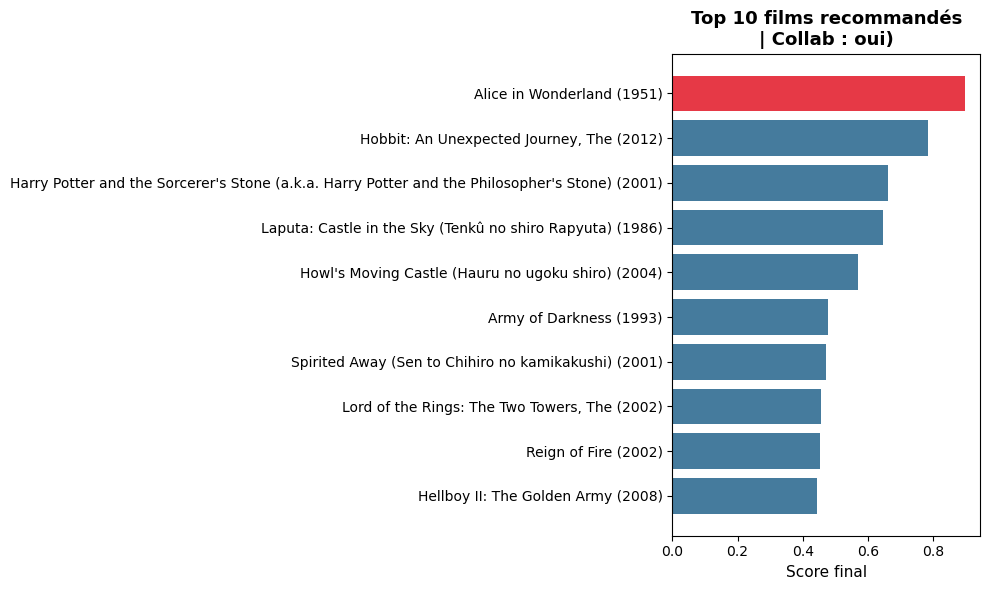

In [83]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

top10_final = final_scores.sort_values(ascending=False).head(10)

top10_labels = []
for tc in top10_final.index:
    match = movies[movies["title_clean"] == tc]
    top10_labels.append(match.iloc[0]["title"] if not match.empty else tc)

colors = ["#e63946" if i == 0 else "#457b9d" for i in range(len(top10_final))]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top10_final)), top10_final.values, color=colors)
ax.set_yticks(range(len(top10_final)))
ax.set_yticklabels(top10_labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Score final", fontsize=11)
ax.set_title(f"Top 10 films recommandés\n| Collab : {'oui' if use_collab else 'non'})",
             fontsize=13, fontweight="bold")

ax.annotate("Recommandé !", xy=(top10_final.values[0], 0),
            xytext=(top10_final.values[0] * 0.5, 0),
            fontsize=10, color="#e63946", fontweight="bold")

plt.tight_layout()
plt.show()

## Modèles + interface

In [ ]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "customtkinter", "gensim"], stdout=subprocess.DEVNULL)

import customtkinter as ctk
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import gensim.downloader as api
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

ctk.set_appearance_mode("dark")
ctk.set_default_color_theme("dark-blue")

app = ctk.CTk()
app.geometry("900x600")
app.title("PickMyMovie")

username = ctk.StringVar()
movies_list = []
use_profile = ctk.BooleanVar()
selected_mood = ctk.StringVar(value="")
rec_vars = []

movies = None
ratings = None
genome_scores = None
genome_tags = None
movie_stats = None
ratings_small = None
movie_vectors = None
genome = None
model = None
tags = None
tag_vectors = None
user_movie_matrix = None
user_similarity_df = None
films_aimes_clean = []
films_aimes_ids = []
use_collab = False
top100_df = None
liked_ids_top20 = []
liked_titles_top20 = []
final_scores = None
mots_mood = []


def load_data():
    global movies, ratings, genome_scores, genome_tags, movie_stats, ratings_small, movie_vectors, genome

    movies = pd.read_csv("movies.csv")
    ratings = pd.read_csv("ratings.csv", nrows=200000)
    genome_scores = pd.read_csv("genome-scores.csv")
    genome_tags_df = pd.read_csv("genome-tags.csv")

    movies["year"] = movies["title"].str.extract(r'\((\d{4})\)').astype(float)
    movies["title_clean"] = (movies["title"].fillna("").astype(str)
                              .str.lower()
                              .str.replace(r"\(.*?\)", "", regex=True)
                              .str.strip())

    ratings["rating"] = pd.to_numeric(ratings["rating"], errors="coerce")

    df_merged = pd.merge(ratings, movies, on="movieId")
    movie_stats = df_merged.groupby("title_clean").agg(
        mean_rating=("rating", "mean"),
        num_ratings=("rating", "count"),
        year=("year", "first"),
        genres=("genres", "first")
    )

    movie_counts = ratings["movieId"].value_counts()
    popular_movies = movie_counts[movie_counts >= 50].index
    ratings_small = ratings[ratings["movieId"].isin(popular_movies)]

    movie_vectors = genome_scores.pivot_table(
        index="movieId", columns="tagId", values="relevance"
    ).fillna(0)
    movie_vectors = movie_vectors.loc[movie_vectors.index.intersection(ratings_small["movieId"])]

    genome = genome_scores.merge(genome_tags_df, on="tagId").merge(movies[["movieId", "title"]], on="movieId")


def load_model():
    global model, tags, tag_vectors
    model = api.load("fasttext-wiki-news-subwords-300")
    df_tags = pd.read_csv("genome-tags.csv")
    tags = df_tags["tag"].astype(str).tolist()
    tag_vectors = np.array([get_vector(tag, model) for tag in tags])
    tag_vectors = normalize(tag_vectors)


def load_collab():
    global user_movie_matrix, user_similarity_df
    top_users = ratings_small["userId"].value_counts().head(3000).index
    ratings_reduced = ratings_small[ratings_small["userId"].isin(top_users)]

    user_movie_matrix = ratings_reduced.pivot_table(
        index="userId", columns="movieId", values="rating"
    ).fillna(0)

    user_similarity_matrix = cosine_similarity(user_movie_matrix)
    user_similarity_df = pd.DataFrame(
        user_similarity_matrix,
        index=user_movie_matrix.index,
        columns=user_movie_matrix.index
    )


def get_vector(text, model):
    if not isinstance(text, str):
        return np.zeros(model.vector_size)
    words = text.lower().split()
    vectors = []
    for word in words:
        if word in model:
            vectors.append(model[word])
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)


def find_similar_tags_v2(input_text, tags, tag_vectors, model, top_n=5):
    input_list = [w.strip().lower() for w in input_text.split(",")]
    results = []
    for word in input_list:
        if word == "":
            continue
        if word in tags:
            idx = tags.index(word)
            word_vec = tag_vectors[idx]
        else:
            word_vec = get_vector(word, model)
        similarities = cosine_similarity(
            word_vec.reshape(1, -1),
            tag_vectors
        )[0]
        top_idx = np.argsort(similarities)[::-1][:top_n]
        for i in top_idx:
            tag = tags[i]
            score = similarities[i] * 100
            results.append((tag, round(score, 2)))
    return np.array(results, dtype=object)


def find_similar_movies_from_tags(similar_tags, df, top_n=100):
    tag_weights = {tag: score for tag, score in similar_tags}
    df_filtered = df[df["tag"].isin(tag_weights.keys())].copy()
    if df_filtered.empty:
        return np.array([], dtype=object)
    df_filtered["user_weight"] = df_filtered["tag"].map(tag_weights)
    df_filtered["weighted_score"] = df_filtered["relevance"] * df_filtered["user_weight"]
    grouped = df_filtered.groupby(["movieId", "title"])
    movie_scores = grouped.apply(
        lambda x: x["weighted_score"].sum() / x["user_weight"].sum()
    )
    top_movies_result = movie_scores.sort_values(ascending=False).head(top_n)
    result = np.array([
        (title, round(score * 100, 2))
        for (movie_id, title), score in top_movies_result.items()
    ], dtype=object)
    return result


def recommander_par_tags(tags_input, top_n=100):
    similar_tags = find_similar_tags_v2(", ".join(tags_input), tags, tag_vectors, model, top_n=5)
    result_array = find_similar_movies_from_tags(similar_tags, genome, top_n=top_n)
    if len(result_array) == 0:
        return pd.DataFrame()
    df_result = pd.DataFrame(result_array, columns=["title", "relevance_score"])
    df_result = df_result.merge(movies[["movieId", "title"]], on="title", how="left")
    return df_result.sort_values("relevance_score", ascending=False).head(top_n)


def score_collaboratif(liked_movie_ids, top_n_users=10):
    pseudo_vector = pd.Series(0.0, index=user_movie_matrix.columns)
    for mid in liked_movie_ids:
        if mid in pseudo_vector.index:
            pseudo_vector[mid] = 5.0

    pseudo_arr = pseudo_vector.values.reshape(1, -1)
    matrix_arr = user_movie_matrix.values
    sims = cosine_similarity(pseudo_arr, matrix_arr).flatten()
    sim_series = pd.Series(sims, index=user_movie_matrix.index)
    similar_uids = sim_series.sort_values(ascending=False).head(top_n_users).index

    similar_ratings = ratings_small[ratings_small["userId"].isin(similar_uids)]
    raw_scores = similar_ratings.groupby("movieId")["rating"].mean()
    popularity = ratings_small.groupby("movieId").size()
    collab_scores = (raw_scores / popularity).fillna(0)
    return collab_scores


def movie_similarity_jaccard(movie1, movie2, w_genre=0.5, w_rating=0.3, w_year=0.2):
    genres1 = set(movie1["genres"].split("|")) if isinstance(movie1["genres"], str) else set()
    genres2 = set(movie2["genres"].split("|")) if isinstance(movie2["genres"], str) else set()
    genre_sim = (len(genres1 & genres2) / len(genres1 | genres2)
                 if (genres1 or genres2) else 0)

    rating_sim = 1 - abs(movie1["mean_rating"] - movie2["mean_rating"]) / 5

    if np.isnan(movie1["year"]) or np.isnan(movie2["year"]):
        year_sim = 0
    else:
        year_sim = max(0, 1 - abs(movie1["year"] - movie2["year"]) / 50)

    return w_genre * genre_sim + w_rating * rating_sim + w_year * year_sim


def score_jaccard(liked_titles_clean, candidate_titles, min_votes=20):
    scores = {}
    liked_stats = []
    for t in liked_titles_clean:
        if t in movie_stats.index:
            liked_stats.append(movie_stats.loc[t])

    if not liked_stats:
        return pd.Series(dtype=float)

    for candidate in candidate_titles:
        if candidate not in movie_stats.index:
            continue
        cand_stat = movie_stats.loc[candidate]
        if cand_stat["num_ratings"] < min_votes:
            continue
        sim_list = [movie_similarity_jaccard(liked, cand_stat) for liked in liked_stats]
        scores[candidate] = np.mean(sim_list)

    return pd.Series(scores)


def clean_title(t):
    return re.sub(r"\(.*?\)", "", t).lower().strip()


def find_movie_in_stats(keyword):
    kw = clean_title(keyword)
    return [t for t in movie_stats.index if kw in t]


def title_to_movieid(title_clean):
    match = movies[movies["title_clean"] == title_clean]
    if not match.empty:
        return match.iloc[0]["movieId"]
    return None


def movieid_to_title(movie_id):
    match = movies[movies["movieId"] == movie_id]
    if not match.empty:
        return match.iloc[0]["title"]
    return str(movie_id)


def normaliser(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series * 0
    return (series - mn) / (mx - mn)


def show_frame(frame):
    frame.tkraise()


container = ctk.CTkFrame(app)
container.pack(fill="both", expand=True)
container.grid_rowconfigure(0, weight=1)
container.grid_columnconfigure(0, weight=1)

frame1 = ctk.CTkFrame(container)
frame2 = ctk.CTkFrame(container)
frame3 = ctk.CTkFrame(container)
frame4 = ctk.CTkFrame(container)
frame5 = ctk.CTkFrame(container)
frame6 = ctk.CTkFrame(container)

for frame in (frame1, frame2, frame3, frame4, frame5, frame6):
    frame.grid(row=0, column=0, sticky="nsew")

ctk.CTkLabel(frame1, text="Indique ton prénom", font=("Arial", 24)).pack(pady=40)
entry_name = ctk.CTkEntry(frame1, placeholder_text="Ton nom")
entry_name.pack(pady=20)


def go_to_movies():
    if entry_name.get().strip() == "":
        return
    username.set(entry_name.get())
    load_data()
    load_model()
    load_collab()
    show_frame(frame2)


ctk.CTkButton(frame1, text="Suivant", command=go_to_movies, fg_color="red").pack(pady=20)

f2_title = ctk.CTkLabel(frame2, text="Un film que tu as aimé", font=("Arial", 20))
f2_title.pack(pady=20)

f2_entry = ctk.CTkEntry(frame2, placeholder_text="Ecris en anglais", width=400)
f2_entry.pack(pady=10)

f2_feedback = ctk.CTkLabel(frame2, text="", font=("Arial", 12), text_color="orange")
f2_feedback.pack(pady=5)

f2_suggestions_frame = ctk.CTkFrame(frame2, fg_color="transparent")
f2_suggestions_frame.pack(pady=5)

f2_added_frame = ctk.CTkFrame(frame2, fg_color="transparent")
f2_added_frame.pack(pady=10)

f2_next_btn = ctk.CTkButton(frame2, text="Suivant", command=lambda: go_to_profile(), fg_color="red", state="disabled")
f2_next_btn.pack(pady=20)

pending_matches = []


def f2_search():
    global pending_matches
    for w in f2_suggestions_frame.winfo_children():
        w.destroy()
    val = f2_entry.get().strip()
    if not val:
        return
    pending_matches = find_movie_in_stats(val)
    if not pending_matches:
        f2_feedback.configure(text="Aucun film trouvé, essaie un autre mot-clé.")
        return
    f2_feedback.configure(text="Choisis un film :")
    for m in pending_matches[:6]:
        display = m.title()
        ctk.CTkButton(
            f2_suggestions_frame,
            text=display,
            width=400,
            fg_color="#333333",
            hover_color="#555555",
            command=lambda chosen=m: f2_add_film(chosen)
        ).pack(pady=3)


def f2_add_film(chosen):
    global films_aimes_clean, films_aimes_ids
    if chosen in films_aimes_clean:
        f2_feedback.configure(text="Film déjà ajouté.")
        return
    mid = title_to_movieid(chosen)
    films_aimes_clean.append(chosen)
    films_aimes_ids.append(mid)

    for w in f2_suggestions_frame.winfo_children():
        w.destroy()
    f2_entry.delete(0, "end")

    n = len(films_aimes_clean)
    ctk.CTkLabel(f2_added_frame, text=f" {chosen.title()}", font=("Arial", 12), text_color="green").pack(anchor="w")

    if n < 5:
        f2_title.configure(text=f"Film {n+1}")
        f2_feedback.configure(text="")
    else:
        f2_title.configure(text="films")
        f2_feedback.configure(text="")
        f2_next_btn.configure(state="normal")


f2_entry.bind("<Return>", lambda e: f2_search())
ctk.CTkButton(frame2, text="🔍 Rechercher", command=f2_search, fg_color="#444444", width=150).pack(pady=5)


def go_to_profile():
    if len(films_aimes_clean) < 5:
        return
    show_frame(frame3)

ctk.CTkLabel(frame3, text="Prendre en compte ton profil ?", font=("Arial", 20)).pack(pady=30)
ctk.CTkCheckBox(frame3, text="Oui, utiliser mon historique", variable=use_profile).pack(pady=10)


def go_to_mood():
    global use_collab
    use_collab = use_profile.get()
    show_frame(frame4)


ctk.CTkButton(frame3, text="Suivant", command=go_to_mood, fg_color="red").pack(pady=20)

ctk.CTkLabel(frame4, text="Décris ton envie de film", font=("Arial", 20)).pack(pady=20)
ctk.CTkLabel(frame4, text="3 groupes de mot en anglais séparé par des virgules)", font=("Arial", 13)).pack(pady=5)
entry_mood = ctk.CTkEntry(frame4, placeholder_text="Tes envies")
entry_mood.pack(pady=15)


def go_to_reco():
    global top100_df, mots_mood, rec_vars
    mood_val = entry_mood.get().strip()
    if mood_val == "":
        return
    mots_mood = [m.strip() for m in mood_val.split(",")][:3]

    tags_films = []
    for title in films_aimes_clean:
        for mot in title.split():
            if len(mot) > 3:
                similar = find_similar_tags_v2(mot, tags, tag_vectors, model, top_n=3)
                tags_films.extend(similar.tolist())

    tags_mood = []
    for mot_mood in mots_mood:
        if mot_mood:
            similar = find_similar_tags_v2(mot_mood, tags, tag_vectors, model, top_n=5)
            tags_mood.extend(similar.tolist())

    input_mood = ", ".join(mots_mood)
    similar_tags = find_similar_tags_v2(input_mood, tags, tag_vectors, model, top_n=5)
    result_array = find_similar_movies_from_tags(similar_tags, genome, top_n=100)

    if len(result_array) == 0:
        top100_df = pd.DataFrame()
    else:
        top100_df = pd.DataFrame(result_array, columns=["title", "relevance_score"])
        top100_df = top100_df.merge(movies[["movieId", "title"]], on="title", how="left")
        top100_df = top100_df[~top100_df["movieId"].isin(films_aimes_ids)].reset_index(drop=True)

    for widget in scroll.winfo_children():
        widget.destroy()
    rec_vars.clear()

    for idx, row in top100_df.iterrows():
        var = ctk.BooleanVar()
        cb = ctk.CTkCheckBox(
            scroll,
            text=row["title"],
            variable=var,
            command=toggle_limit
        )
        cb.pack(anchor="w", padx=10, pady=5)
        rec_vars.append((row["title"], var, row["movieId"]))

    show_frame(frame5)


ctk.CTkButton(frame4, text="Suivant", command=go_to_reco, fg_color="red").pack(pady=40)

ctk.CTkLabel(frame5, text="Coche jusqu'à 5 films que tu aimes et que tu as vus", font=("Arial", 20)).pack(pady=10)
scroll = ctk.CTkScrollableFrame(frame5, width=700, height=350)
scroll.pack(pady=10)
rec_vars = []


def toggle_limit():
    count = sum(var.get() for _, var, _ in rec_vars)
    if count > 5:
        for name, var, mid in reversed(rec_vars):
            if var.get():
                var.set(False)
                break


def go_to_top5():
    global liked_ids_top20, liked_titles_top20, final_scores

    selected_entries = [(name, var, mid) for name, var, mid in rec_vars if var.get()]
    if len(selected_entries) == 0:
        liked_ids_top20 = films_aimes_ids
        liked_titles_top20 = films_aimes_clean
    else:
        liked_ids_top20 = [mid for _, _, mid in selected_entries]
        liked_titles_top20 = []
        for mid in liked_ids_top20:
            tc = movies[movies["movieId"] == mid]["title_clean"]
            if not tc.empty:
                liked_titles_top20.append(tc.values[0])

    candidate_movieids = top100_df["movieId"].tolist()
    candidate_title_clean = []
    for mid in candidate_movieids:
        tc = movies[movies["movieId"] == mid]["title_clean"]
        if not tc.empty:
            candidate_title_clean.append(tc.values[0])

    jaccard_scores = score_jaccard(liked_titles_top20, candidate_title_clean)
    jaccard_scores = normaliser(jaccard_scores)

    if use_collab:
        collab_scores_raw = score_collaboratif(liked_ids_top20)
        collab_scores_aligned = collab_scores_raw.reindex(
            [title_to_movieid(t) for t in jaccard_scores.index]
        ).fillna(0)
        collab_scores_aligned.index = jaccard_scores.index
        collab_scores_norm = normaliser(collab_scores_aligned)
        final_scores = 0.6 * jaccard_scores + 0.4 * collab_scores_norm
    else:
        final_scores = jaccard_scores

    tous_vus_clean = liked_titles_top20 + films_aimes_clean
    final_scores = final_scores[~final_scores.index.isin(tous_vus_clean)]

    top5 = final_scores.sort_values(ascending=False).head(5)
    top5_titles = []
    for tc in top5.index:
        match = movies[movies["title_clean"] == tc]
        top5_titles.append(match.iloc[0]["title"] if not match.empty else tc)

    medals = ["🥇", "🥈", "🥉", "4.", "5."]
    sizes = [20, 18, 16, 14, 14]
    for widget in frame6.winfo_children():
        widget.destroy()

    ctk.CTkLabel(frame6, text="Top 5 meilleurs films recommandés pour toi", font=("Arial", 22)).pack(pady=20)
    for i, title in enumerate(top5_titles):
        bold = "bold" if i == 0 else "normal"
        ctk.CTkLabel(frame6, text=f"{medals[i]} {title}", font=("Arial", sizes[i], bold)).pack(pady=10)

    show_frame(frame6)


ctk.CTkButton(frame5, text="Valider", command=go_to_top5, fg_color="red").pack(pady=10)

ctk.CTkLabel(frame6, text="Top 5 meilleurs films qu'on recommande pour toi", font=("Arial", 22)).pack(pady=20)

show_frame(frame1)
app.mainloop()

bgerror failed to handle background error.
    Original error: invalid command name "14133921088update"
    Error in bgerror: can't invoke "tk" command: application has been destroyed
bgerror failed to handle background error.
    Original error: invalid command name "14138570432check_dpi_scaling"
    Error in bgerror: can't invoke "tk" command: application has been destroyed
